In [1]:
import sys
print(sys.executable)

c:\Users\harsh\OneDrive - University of Bristol\Desktop\EBM-NLP-master\.venv\Scripts\python.exe


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
print("All imports done ✅")

c:\Users\harsh\OneDrive - University of Bristol\Desktop\EBM-NLP-master\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports done ✅


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
DATA_DIR = r'C:\Users\harsh\OneDrive - University of Bristol\Desktop\EBM-NLP-master\ebm-nlp-project\data\ebm_nlp_2_00'

def load_abstracts(data_dir):
    abstracts = {}
    doc_dir = os.path.join(data_dir, 'documents')
    for filename in os.listdir(doc_dir):
        if filename.endswith('.txt'):
            pmid = filename.replace('.txt', '')
            with open(os.path.join(doc_dir, filename), 'r', encoding='utf-8') as f:
                abstracts[pmid] = f.read().strip()
    return abstracts

abstracts = load_abstracts(DATA_DIR)
print(f"Total abstracts loaded: {len(abstracts)}")
# Should show 4993

Total abstracts loaded: 4993


In [4]:
def load_labels(data_dir, pmid, element):
    label_path = os.path.join(
        data_dir,
        'annotations', 'aggregated',
        'starting_spans', element,
        'train',
        f'{pmid}.AGGREGATED.ann'
    )
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            labels = [int(x) for x in f.read().strip().split()]
        return labels
    return None

# Test on first abstract
pmid = list(abstracts.keys())[0]
p_labels = load_labels(DATA_DIR, pmid, 'participants')
i_labels = load_labels(DATA_DIR, pmid, 'interventions')
o_labels = load_labels(DATA_DIR, pmid, 'outcomes')

print(f"Sample PMID: {pmid}")
print(f"Abstract: {abstracts[pmid][:200]}")
print(f"P labels: {p_labels[:10] if p_labels else 'Not found'}")
print(f"I labels: {i_labels[:10] if i_labels else 'Not found'}")
print(f"O labels: {o_labels[:10] if o_labels else 'Not found'}")

Sample PMID: 10036953
Abstract: [Triple therapy regimens involving H2 blockaders for therapy of Helicobacter pylori infections].

Comparison of ranitidine and lansoprazole in short-term low-dose triple therapy for Helicobacter pylor
P labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
I labels: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
O labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
all_sentences = []
all_pmids = []

for pmid, text in abstracts.items():
    sentences = sent_tokenize(text)
    for sent in sentences:
        if len(sent.strip()) > 10:
            all_sentences.append(sent)
            all_pmids.append(pmid)

print(f"Total sentences: {len(all_sentences)}")


Total sentences: 53351


In [ ]:
# DON'T regenerate — load from saved file
RESULTS_DIR = r'C:\Users\harsh\OneDrive - University of Bristol\Desktop\EBM-NLP-master\ebm-nlp-project\results'

embeddings = np.load(os.path.join(RESULTS_DIR, 'embeddings.npy'))
print(f"Embeddings loaded: {embeddings.shape} ✅")


Embeddings loaded: (53351, 384) ✅


In [7]:
print("Running K-Means...")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(embeddings)

unique, counts = np.unique(kmeans_labels, return_counts=True)
print("\nK-Means Cluster sizes:")
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} sentences")

print("\nExample sentences per cluster:")
for cluster_id in range(3):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(kmeans_labels == cluster_id)[0][:3]
    for idx in indices:
        print(f"  {all_sentences[idx][:100]}")

Running K-Means...

K-Means Cluster sizes:
  Cluster 0: 13211 sentences
  Cluster 1: 20014 sentences
  Cluster 2: 20126 sentences

Example sentences per cluster:

--- Cluster 0 ---
  Rhinocort Study Group.
  Secondarily to ascertain patients' preferences for the two nasal devices and to assess quality of li
  DESIGN Randomized, multicentre, double-blind, double- dummy, parallel groups study.

--- Cluster 1 ---
  [Triple therapy regimens involving H2 blockaders for therapy of Helicobacter pylori infections].
  Comparison of ranitidine and lansoprazole in short-term low-dose triple therapy for Helicobacter pyl
  To evaluate the efficacy and safety of two 1-week low-dose triple-therapy drug regimens involving an

--- Cluster 2 ---
  Pre-operative short-term pulmonary rehabilitation for patients of chronic obstructive pulmonary dise
  The role of pre-operative short-term pulmonary rehabilitation in patients with chronic obstructive p
  Forty-five patients posted for coronary artery bypass 

In [15]:
print("Running HAC on 500 sentences...")

sample_size = 500
sample_embeddings = embeddings[:sample_size]
sample_sentences = all_sentences[:sample_size]

hac = AgglomerativeClustering(n_clusters=3, linkage='ward')
hac_labels = hac.fit_predict(sample_embeddings)

unique, counts = np.unique(hac_labels, return_counts=True)
print("\nHAC Cluster sizes:")
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} sentences")

print("HAC done ✅")

Running HAC on 500 sentences...

HAC Cluster sizes:
  Cluster 0: 260 sentences
  Cluster 1: 51 sentences
  Cluster 2: 189 sentences
HAC done ✅


In [16]:
print("Calculating Silhouette scores...")

sil_kmeans = silhouette_score(
    embeddings[:500],
    kmeans_labels[:500],
    metric='euclidean'
)

sil_hac = silhouette_score(
    embeddings[:500],
    hac_labels,
    metric='euclidean'
)

print(f"K-Means Silhouette Score: {sil_kmeans:.3f}")
print(f"HAC Silhouette Score:     {sil_hac:.3f}")
print(f"\nInterpretation:")
print(f"  > 0.5  = strong clusters")
print(f"  > 0.25 = reasonable clusters")
print(f"  < 0.25 = weak clusters")

Calculating Silhouette scores...
K-Means Silhouette Score: 0.036
HAC Silhouette Score:     0.028

Interpretation:
  > 0.5  = strong clusters
  > 0.25 = reasonable clusters
  < 0.25 = weak clusters


Generating UMAP visualisation...


c:\Users\harsh\OneDrive - University of Bristol\Desktop\EBM-NLP-master\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


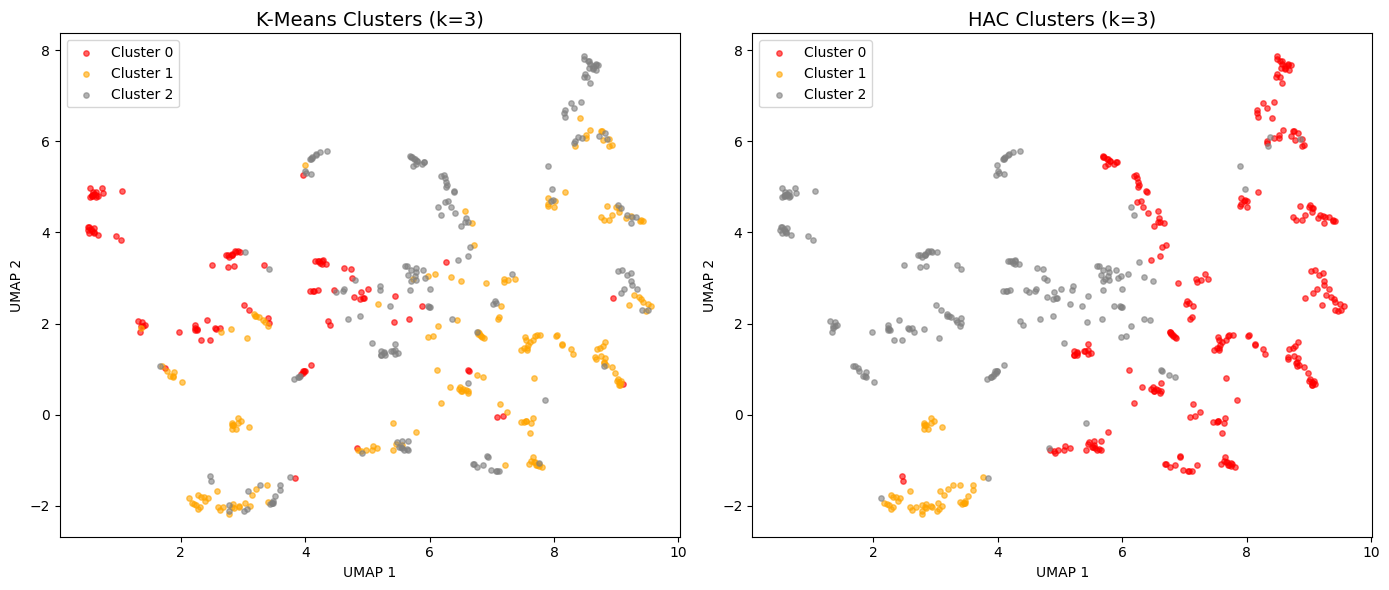

UMAP plot saved ✅


In [17]:
print("Generating UMAP visualisation...")

reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings[:500])

colors = ['red', 'orange', 'grey']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cluster_id in range(3):
    mask = kmeans_labels[:500] == cluster_id
    axes[0].scatter(
        embedding_2d[mask, 0], embedding_2d[mask, 1],
        c=colors[cluster_id], alpha=0.6, s=15,
        label=cluster_names[cluster_id]
    )
axes[0].set_title('K-Means Clusters (k=3)', fontsize=14)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend()

for cluster_id in range(3):
    mask = hac_labels == cluster_id
    axes[1].scatter(
        embedding_2d[mask, 0], embedding_2d[mask, 1],
        c=colors[cluster_id], alpha=0.6, s=15,
        label=cluster_names[cluster_id]
    )
axes[1].set_title('HAC Clusters (k=3)', fontsize=14)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'clustering_plot.png'), dpi=150)
plt.show()
print("UMAP plot saved ✅")

Generating Dendrogram...


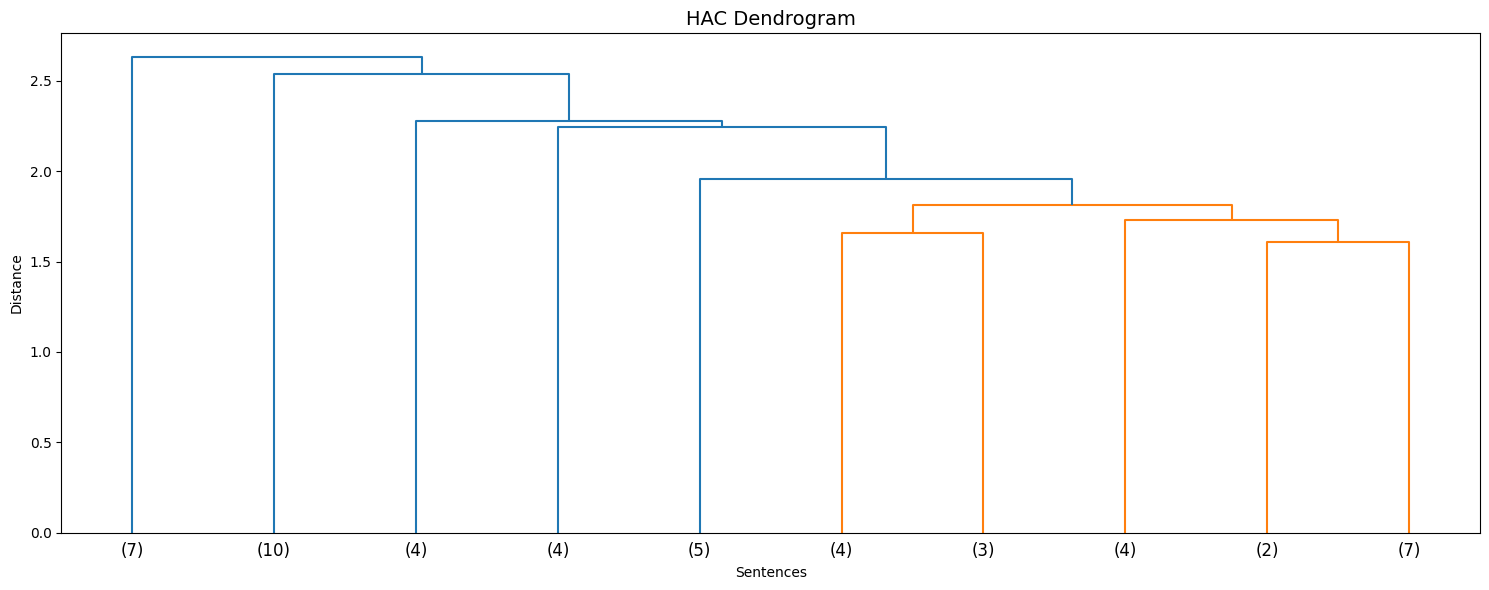

Dendrogram saved ✅


In [18]:
print("Generating Dendrogram...")

tiny_sample = embeddings[:50]
linked = linkage(tiny_sample, method='ward')

plt.figure(figsize=(15, 6))
dendrogram(linked, truncate_mode='lastp', p=10)
plt.title('HAC Dendrogram', fontsize=14)
plt.xlabel('Sentences')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dendrogram.png'), dpi=150)
plt.show()
print("Dendrogram saved ✅")

In [19]:
def get_dominant_label(data_dir, pmid):
    p = load_labels(data_dir, pmid, 'participants')
    i = load_labels(data_dir, pmid, 'interventions')
    o = load_labels(data_dir, pmid, 'outcomes')

    if p is None or i is None or o is None:
        return -1

    p_count = sum(1 for x in p if x > 0)
    i_count = sum(1 for x in i if x > 0)
    o_count = sum(1 for x in o if x > 0)

    if max(p_count, i_count, o_count) == 0:
        return -1

    return [p_count, i_count, o_count].index(
        max(p_count, i_count, o_count)
    )

print("Building true labels...")
true_labels = []
for idx in range(500):
    pmid = all_pmids[idx]
    label = get_dominant_label(DATA_DIR, pmid)
    true_labels.append(label)

true_labels = np.array(true_labels)

valid_mask = true_labels != -1
true_valid = true_labels[valid_mask]
kmeans_valid = kmeans_labels[:500][valid_mask]
hac_valid = hac_labels[valid_mask]

ari_kmeans = adjusted_rand_score(true_valid, kmeans_valid)
nmi_kmeans = normalized_mutual_info_score(true_valid, kmeans_valid)
ari_hac = adjusted_rand_score(true_valid, hac_valid)
nmi_hac = normalized_mutual_info_score(true_valid, hac_valid)

print(f"\n--- Final Evaluation Results ---")
print(f"K-Means ARI:       {ari_kmeans:.3f}")
print(f"K-Means NMI:       {nmi_kmeans:.3f}")
print(f"K-Means Silhouette:{sil_kmeans:.3f}")
print(f"\nHAC ARI:           {ari_hac:.3f}")
print(f"HAC NMI:           {nmi_hac:.3f}")
print(f"HAC Silhouette:    {sil_hac:.3f}")

Building true labels...

--- Final Evaluation Results ---
K-Means ARI:       0.038
K-Means NMI:       0.038
K-Means Silhouette:0.036

HAC ARI:           0.034
HAC NMI:           0.063
HAC Silhouette:    0.028
